# Defensive AI — Autoencoder Anomaly Detection
## PFE 2025 — Mohamed Bouzira & Bakhti Rayane Abderaouef

**Objective:** Train an autoencoder on **benign-only** traffic to learn "normal" patterns, then detect attacks as **anomalies** (high reconstruction error) on 244K+ balanced honeypot logs.

**Pipeline:**
1. Load & Explore Data
2. EDA & Class Distribution
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Feature Selection
6. Scaling (MinMaxScaler)
7. Train/Test Split (benign-only training)
8. Autoencoder Architecture (with BatchNorm + Dropout)
9. Training with EarlyStopping
10. Reconstruction Loss Analysis
11. Threshold Selection (percentile sweep)
12. Evaluation (Confusion Matrix, ROC, PR curve)
13. Per-Attack-Type Analysis
14. Latent Space Visualization (t-SNE)
15. Save Model

In [1]:
# ================================================================
# Cell 1: Install Dependencies & Imports
# ================================================================
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


In [2]:
# ================================================================
# Cell 2: Load Dataset
# ================================================================
df = pd.read_csv('honeypot_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'\nColumn types:\n{df.dtypes.value_counts()}')
df.head()

Dataset shape: (105576, 46)
Memory usage: 167.3 MB

Column types:
object     26
float64    19
bool        1
Name: count, dtype: int64


,bytes_sent,bytes_received,src_port,dst_port,payload_size,body_size,qos,msg_rate_per_min,req_rate_per_min,session_msg_count,session_topic_count,session_req_count,session_endpoint_count,session_path_count,session_duration_s,http_status_code,packet_count,pps,window_seconds,attack_type,is_attack,log_type,protocol,@timestamp,src_ip,dst_ip,is_internal,is_known_device,mqtt_action,client_id,topic,retain,is_known_topic,http_method,http_endpoint,user_agent,coap_method,coap_path,coap_response_code,is_known_path,eventid,username,login_success,attack_name,login_attempt,username_tried
0,96.707507,0.0,0.000000,1883.0,96.707507,0.0,0.0,15.471671,0.000000,2.17611,4.588055,0.000000,0.000000,0.000000,346.590519,0.0,0.0,0.0,0.0,topic_anomaly,True,mqtt,MQTT,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
1,0.000000,0.0,52243.150625,5683.0,0.000000,0.0,0.0,0.000000,20.657833,0.00000,0.000000,6.625292,0.000000,7.171083,43.636853,0.0,0.0,0.0,0.0,path_scan,True,coap,CoAP,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
2,0.000000,0.0,0.000000,1883.0,0.000000,0.0,0.0,6.632874,0.000000,1.55069,2.000000,0.000000,0.000000,0.000000,27.121866,0.0,0.0,0.0,0.0,wildcard_scan,True,mqtt,MQTT,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
3,0.000000,0.0,58798.000000,5683.0,0.000000,0.0,0.0,0.000000,9.000000,0.00000,0.000000,3128.000000,0.000000,2.000000,20859.190000,0.0,0.0,0.0,0.0,benign,False,coap,CoAP,2026-04-22T06:27:39.600Z,172.20.0.15,172.20.0.2,True,True,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,GET,home/motion/command,2.05 Content,True,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
4,33.000000,0.0,38778.000000,80.0,0.000000,33.0,0.0,0.000000,19.000000,0.00000,0.000000,34.769437,34.769437,0.000000,111.122224,404.0,0.0,0.0,0.0,unknown_external,True,platform,HTTP,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic


# Cell 3: EDA & Class Distribution

DATASET OVERVIEW FOR ANOMALY DETECTION

Total samples: 105,576
Benign samples: 32,531
Attack samples: 73,045
Attack ratio: 69.19%

Attack types:
attack_type
benign              32531
endpoint_scan        5363
scan                 5280
topic_anomaly        5260
port_scan            5258
path_traversal       5235
unknown              5222
wildcard_scan        5220
exploit              5204
unknown_external     5194
brute_force          5187
unknown_client       5183
ddos                 5181
path_scan            5170
large_payload        5088
Name: count, dtype: int64


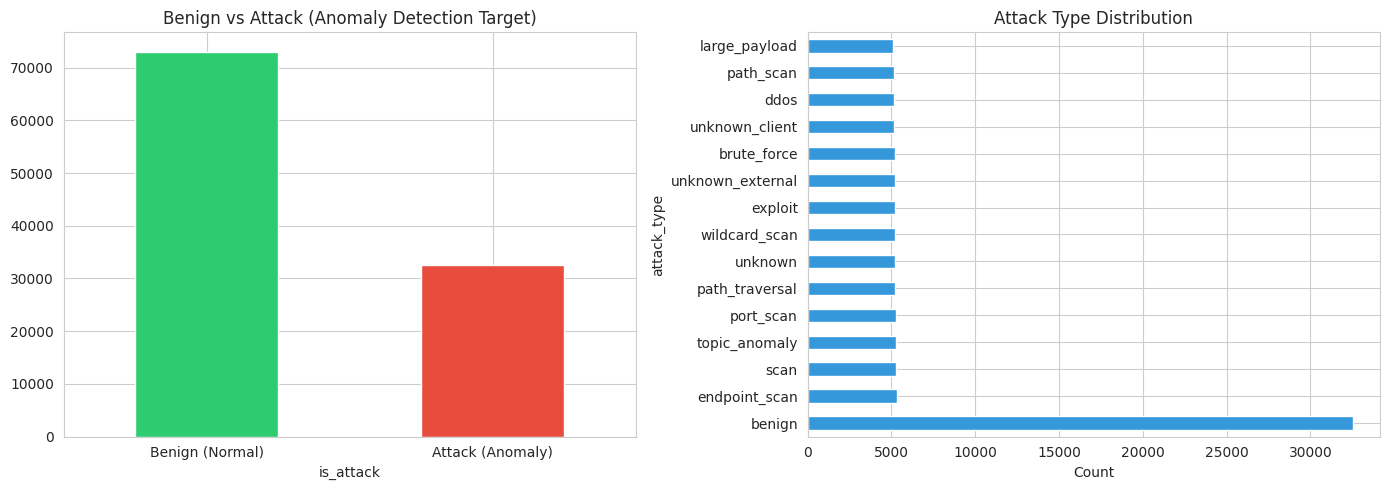

In [3]:
# ================================================================
# Cell 3: EDA & Class Distribution
# ================================================================
print('=' * 60)
print('DATASET OVERVIEW FOR ANOMALY DETECTION')
print('=' * 60)

print(f'\nTotal samples: {len(df):,}')
print(f'Benign samples: {(df["is_attack"] == False).sum():,}')
print(f'Attack samples: {(df["is_attack"] == True).sum():,}')
print(f'Attack ratio: {df["is_attack"].mean():.2%}')

print(f'\nAttack types:')
print(df['attack_type'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['is_attack'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Benign vs Attack (Anomaly Detection Target)')
axes[0].set_xticklabels(['Benign (Normal)', 'Attack (Anomaly)'], rotation=0)

df['attack_type'].value_counts().plot.barh(ax=axes[1], color='#3498db')
axes[1].set_title('Attack Type Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Cell 4: Data Cleaning & Preprocessing

In [4]:
# ================================================================
# Cell 4: Data Cleaning & Preprocessing
# ================================================================
data = df.copy()

# Drop columns not useful for anomaly detection
drop_cols = [
    '@timestamp', 'src_ip', 'dst_ip', 'client_id', 'topic',
    'http_endpoint', 'user_agent', 'coap_path',
    'username', 'username_tried', 'attack_name',
    'command',
    # Target leakage — in our honeypot ALL benign=internal+known, ALL attack=external+unknown
    'is_internal', 'is_known_device',
]
data.drop(columns=[c for c in drop_cols if c in data.columns], inplace=True)
print(f'Dropped {len(drop_cols)} identifier/leaky columns')

# --- Replace "synthetic" marker (from SMOTE) with NaN to avoid artifact leakage ---
data.replace("synthetic", np.nan, inplace=True)

# Fix boolean columns
bool_fix = ['retain', 'is_known_topic', 'is_known_path', 'login_success', 'login_attempt']
for col in bool_fix:
    if col in data.columns:
        data[col] = data[col].map({'True': 1, 'False': 0, True: 1, False: 0,
                                    'true': 1, 'false': 0}).astype('float64')

# Convert target
data['is_attack'] = data['is_attack'].astype(int)

# Fill NaN
nan_before = data.isnull().sum().sum()
data.fillna(0, inplace=True)
print(f'Filled {nan_before:,} NaN values')

print(f'\nCleaned shape: {data.shape}')

Dropped 14 identifier/leaky columns
Filled 965,278 NaN values

Cleaned shape: (105576, 33)


# Cell 5: Feature Engineering

In [5]:
# ================================================================
# Cell 5: Feature Engineering
# ================================================================
# 1. Bytes ratio
data['bytes_ratio'] = data['bytes_sent'] / (data['bytes_received'] + 1)

# 2. Total bytes
data['total_bytes'] = data['bytes_sent'] + data['bytes_received']

# 3. Port class
def port_class(port):
    if port <= 1023: return 0
    elif port <= 49151: return 1
    else: return 2

data['src_port_class'] = data['src_port'].apply(port_class)
data['dst_port_class'] = data['dst_port'].apply(port_class)

# 4. High rate flags
for col in ['msg_rate_per_min', 'req_rate_per_min']:
    if col in data.columns:
        threshold = data[col][data[col] > 0].quantile(0.90) if (data[col] > 0).any() else 0
        data[f'{col}_high'] = (data[col] > threshold).astype(int)

# 5. Session intensity
if 'msg_rate_per_min' in data.columns and 'session_msg_count' in data.columns:
    data['mqtt_session_intensity'] = data['msg_rate_per_min'] * data['session_msg_count']
if 'req_rate_per_min' in data.columns and 'session_req_count' in data.columns:
    data['http_session_intensity'] = data['req_rate_per_min'] * data['session_req_count']

# 6. Session diversity
diversity_cols = ['session_topic_count', 'session_endpoint_count', 'session_path_count']
data['session_diversity'] = data[[c for c in diversity_cols if c in data.columns]].sum(axis=1)

print(f'Shape after feature engineering: {data.shape}')

Shape after feature engineering: (105576, 42)


# Cell 6: Feature Selection & Encoding

In [6]:
# ================================================================
# Cell 6: Feature Selection & Encoding
# ================================================================
from sklearn.feature_selection import VarianceThreshold

# Keep attack_type for per-type analysis later
attack_types = data['attack_type'].copy()

# One-hot encode categoricals
cat_cols = ['log_type', 'protocol', 'mqtt_action', 'http_method',
            'coap_method', 'coap_response_code', 'eventid']
cat_cols = [c for c in cat_cols if c in data.columns]
data = pd.get_dummies(data, columns=cat_cols, drop_first=False)

# Drop target columns for feature matrix
data.drop(columns=['attack_type'], inplace=True)

# Variance threshold
X_temp = data.drop(columns=['is_attack'])
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_temp)
low_var = X_temp.columns[~selector.get_support()].tolist()
if low_var:
    data.drop(columns=low_var, inplace=True)
    print(f'Dropped {len(low_var)} low-variance features')

# Remove highly correlated (>0.95)
X_temp = data.drop(columns=['is_attack'])
corr_abs = X_temp.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
if high_corr:
    data.drop(columns=high_corr, inplace=True)
    print(f'Dropped {len(high_corr)} highly correlated features')

print(f'\nFinal feature shape: {data.shape}')
print(f'Features for autoencoder: {data.shape[1] - 1}')

Dropped 18 low-variance features
Dropped 16 highly correlated features

Final feature shape: (105576, 36)
Features for autoencoder: 35


# Cell 7: Scaling & Train/Test Split (Benign-Only Training)

In [7]:
# ================================================================
# Cell 7: Scaling & Train/Test Split
# ================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
X = data.drop(columns=['is_attack'])
y = data['is_attack']
feature_names = X.columns.tolist()
input_dim = X.shape[1]

print(f'Input dimension: {input_dim}')
print(f'Total benign: {(y == 0).sum():,}')
print(f'Total attack: {(y == 1).sum():,}')

# Split: use ONLY benign data for training the autoencoder
X_benign = X[y == 0]
X_attack = X[y == 1]
y_attack_types = attack_types[y == 1]

# Split benign into train/val
X_train_b, X_val_b = train_test_split(X_benign, test_size=0.2, random_state=42)

# Test set: val benign + all attacks
X_test = pd.concat([X_val_b, X_attack], axis=0)
y_test = np.concatenate([np.zeros(len(X_val_b)), np.ones(len(X_attack))])
test_attack_types = pd.concat([
    pd.Series(['benign'] * len(X_val_b)),
    y_attack_types.reset_index(drop=True)
], ignore_index=True)

# Scale with MinMaxScaler (fitted on benign training data only)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_b)
X_val_scaled = scaler.transform(X_val_b)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain (benign only): {X_train_scaled.shape[0]:,}')
print(f'Validation (benign only): {X_val_scaled.shape[0]:,}')
print(f'Test (benign + attack): {X_test_scaled.shape[0]:,} ({int(y_test.sum()):,} attacks)')

Input dimension: 35
Total benign: 32,531
Total attack: 73,045

Train (benign only): 26,024
Validation (benign only): 6,507
Test (benign + attack): 79,552 (73,045 attacks)


# Cell 8: Autoencoder Architecture

In [8]:
# ================================================================
# Cell 8: Autoencoder Architecture
# ================================================================
# Deeper architecture with BatchNorm and Dropout for regularization

# Encoder
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
bottleneck = layers.Dense(32, activation='relu', name='bottleneck')(x)

# Decoder
x = layers.Dense(64, activation='relu')(bottleneck)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(input_dim, activation='sigmoid')(x)

autoencoder = Model(inputs, outputs, name='anomaly_autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')

# Also create encoder model for latent space visualization
encoder = Model(inputs, bottleneck, name='encoder')

autoencoder.summary()

Model: "anomaly_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,427 (122.76 KB)

 Trainable params: 30,659 (119.76 KB)

 Non-trainable params: 768 (3.00 KB)

# Cell 9: Training with EarlyStopping

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 0.1064 - val_loss: 0.0474
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0148 - val_loss: 0.0175
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - val_loss: 0.0078
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 - val_loss: 0.0030
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - val_loss: 7.3276e-04
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014 - val_loss: 6.5887e-04
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 4.9958e-04
Epoch 10/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - val_loss: 4.8199e-04
Epoch 11/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 4.6221e-04
Epoch 12/100
102/10

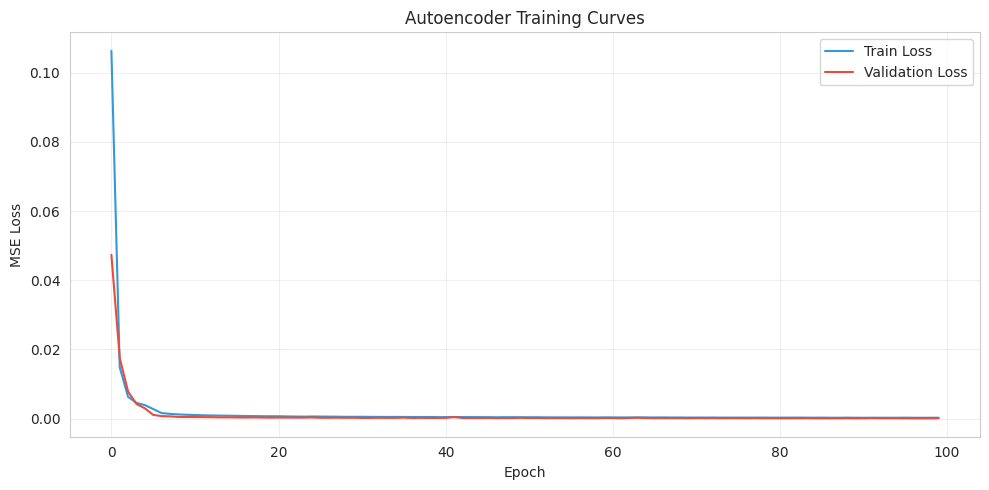


Best epoch: -9
Final train loss: 0.000257
Final val loss: 0.000120


In [9]:
# ================================================================
# Cell 9: Training with EarlyStopping
# ================================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,  # input = output (reconstruct itself)
    epochs=100,
    batch_size=256,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1,
)

# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Train Loss', color='#3498db')
ax.plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nBest epoch: {early_stop.stopped_epoch - early_stop.patience + 1}')
print(f'Final train loss: {history.history["loss"][-1]:.6f}')
print(f'Final val loss: {history.history["val_loss"][-1]:.6f}')

# Cell 10: Reconstruction Loss Analysis

Reconstruction Error Statistics:
  Benign — mean: 0.000090, std: 0.000805, median: 0.000039
  Attack — mean: 13.487661, std: 43.278515, median: 0.070121

  Separation ratio (attack_mean / benign_mean): 149397.41x


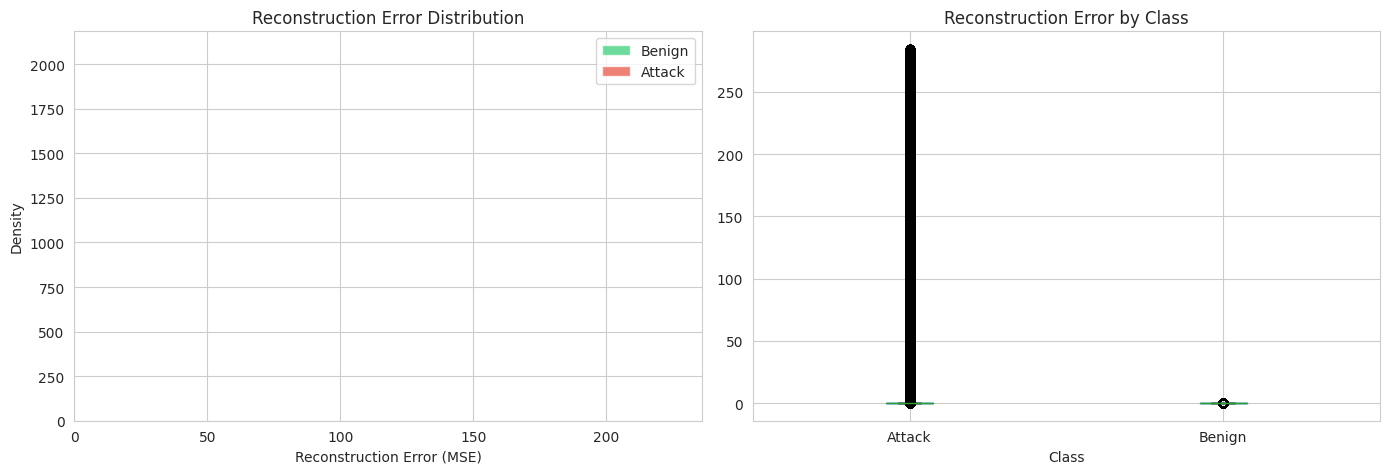

In [10]:
# ================================================================
# Cell 10: Reconstruction Loss Analysis
# ================================================================
# Compute reconstruction error for test set
X_test_pred = autoencoder.predict(X_test_scaled, verbose=0)
recon_error = np.mean((X_test_scaled - X_test_pred) ** 2, axis=1)

# Separate benign vs attack reconstruction errors
recon_benign = recon_error[y_test == 0]
recon_attack = recon_error[y_test == 1]

print('Reconstruction Error Statistics:')
print(f'  Benign — mean: {recon_benign.mean():.6f}, std: {recon_benign.std():.6f}, '
      f'median: {np.median(recon_benign):.6f}')
print(f'  Attack — mean: {recon_attack.mean():.6f}, std: {recon_attack.std():.6f}, '
      f'median: {np.median(recon_attack):.6f}')
print(f'\n  Separation ratio (attack_mean / benign_mean): {recon_attack.mean() / recon_benign.mean():.2f}x')

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(recon_benign, bins=100, alpha=0.7, label='Benign', color='#2ecc71', density=True)
axes[0].hist(recon_attack, bins=100, alpha=0.7, label='Attack', color='#e74c3c', density=True)
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Reconstruction Error Distribution')
axes[0].legend()
axes[0].set_xlim(0, np.percentile(recon_error, 99))

# Box plot
import pandas as pd
box_data = pd.DataFrame({'Reconstruction Error': recon_error, 'Class': ['Benign' if y == 0 else 'Attack' for y in y_test]})
box_data.boxplot(column='Reconstruction Error', by='Class', ax=axes[1])
axes[1].set_title('Reconstruction Error by Class')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Cell 11: Threshold Selection (Percentile Sweep)

Threshold Sweep Results:
 percentile  threshold       f1  precision   recall
         85   0.000083 0.991086   0.986755 0.995455
         90   0.000103 0.992839   0.991119 0.994565
         91   0.000108 0.993218   0.991997 0.994442
         92   0.000115 0.993556   0.992877 0.994236
         93   0.000121 0.993929   0.993759 0.994100
         94   0.000128 0.994193   0.994642 0.993744
         95   0.000138 0.994443   0.995527 0.993360
         96   0.000157 0.994631   0.996414 0.992854
         97   0.000189 0.994660   0.997302 0.992032
         98   0.000232 0.994759   0.998194 0.991348
         99   0.000434 0.994596   0.999088 0.990143

Best threshold: 0.000232 (at 98.0th percentile)
  F1: 0.9948, Precision: 0.9982, Recall: 0.9913


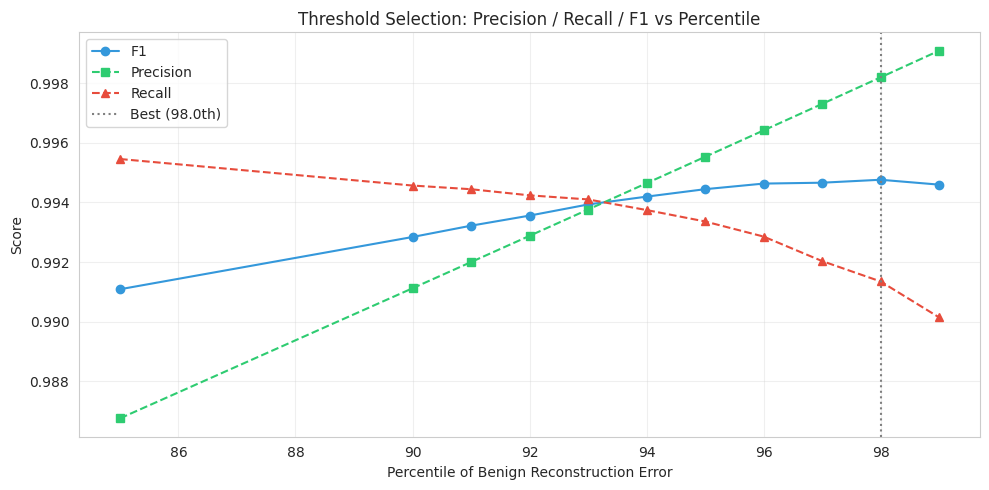

In [11]:
# ================================================================
# Cell 11: Threshold Selection
# ================================================================
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             precision_recall_curve)

# Sweep over percentiles of benign reconstruction error
percentiles = [85, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
results = []

for pct in percentiles:
    threshold = np.percentile(recon_benign, pct)
    y_pred = (recon_error > threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    results.append({'percentile': pct, 'threshold': threshold,
                    'f1': f1, 'precision': prec, 'recall': rec})

results_df = pd.DataFrame(results)
print('Threshold Sweep Results:')
print('=' * 70)
print(results_df.to_string(index=False))

# Select best threshold by F1
best_row = results_df.loc[results_df['f1'].idxmax()]
threshold = best_row['threshold']
print(f'\nBest threshold: {threshold:.6f} (at {best_row["percentile"]}th percentile)')
print(f'  F1: {best_row["f1"]:.4f}, Precision: {best_row["precision"]:.4f}, Recall: {best_row["recall"]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['percentile'], results_df['f1'], 'o-', label='F1', color='#3498db')
ax.plot(results_df['percentile'], results_df['precision'], 's--', label='Precision', color='#2ecc71')
ax.plot(results_df['percentile'], results_df['recall'], '^--', label='Recall', color='#e74c3c')
ax.axvline(x=best_row['percentile'], color='gray', linestyle=':', label=f'Best ({best_row["percentile"]}th)')
ax.set_xlabel('Percentile of Benign Reconstruction Error')
ax.set_ylabel('Score')
ax.set_title('Threshold Selection: Precision / Recall / F1 vs Percentile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cell 12: Full Evaluation (Confusion Matrix, ROC, PR Curve)

AUTOENCODER ANOMALY DETECTION RESULTS
              precision    recall  f1-score   support

      Benign       0.91      0.98      0.94      6507
      Attack       1.00      0.99      0.99     73045

    accuracy                           0.99     79552
   macro avg       0.95      0.99      0.97     79552
weighted avg       0.99      0.99      0.99     79552

ROC AUC: 0.9974
Average Precision (PR AUC): 0.9998


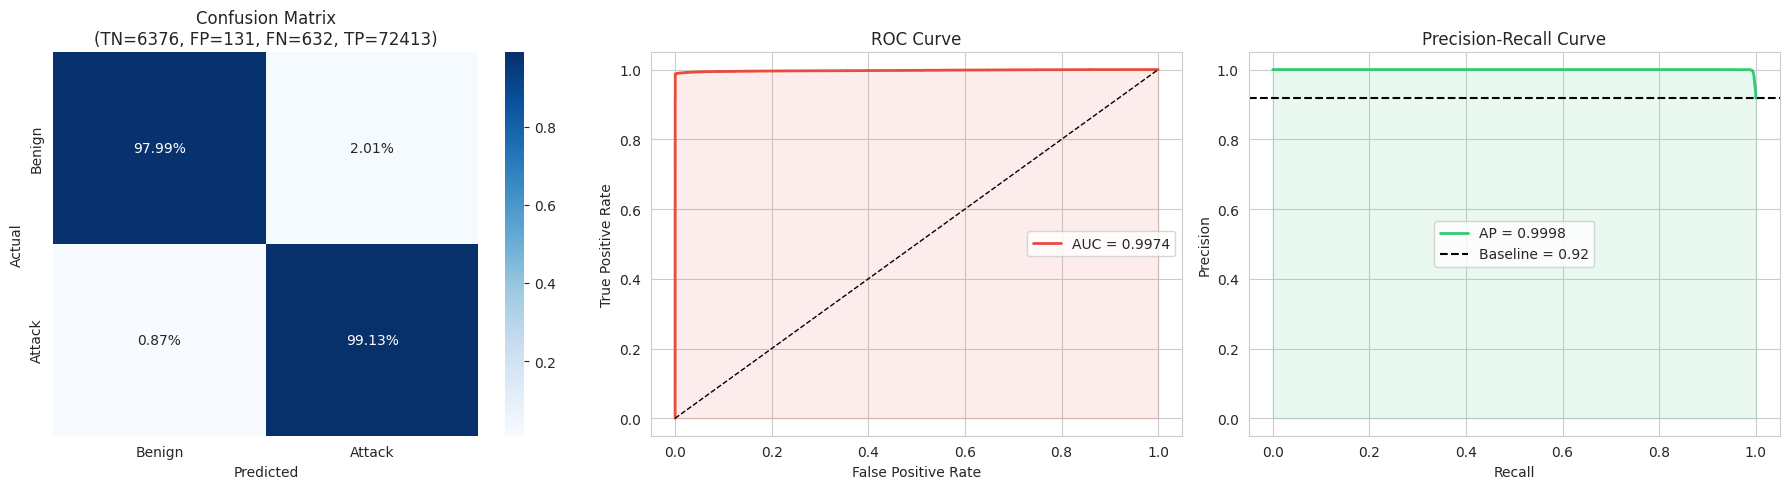

In [12]:
# ================================================================
# Cell 12: Full Evaluation
# ================================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, average_precision_score)

y_pred = (recon_error > threshold).astype(int)

print('=' * 60)
print('AUTOENCODER ANOMALY DETECTION RESULTS')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

roc_auc = roc_auc_score(y_test, recon_error)
ap = average_precision_score(y_test, recon_error)
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Average Precision (PR AUC): {ap:.4f}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix\n(TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]})')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, recon_error)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, recon_error)
axes[2].plot(recall, precision, color='#2ecc71', lw=2, label=f'AP = {ap:.4f}')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline = {y_test.mean():.2f}')
axes[2].fill_between(recall, precision, alpha=0.1, color='#2ecc71')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
plt.show()

# Cell 13: Per-Attack-Type Reconstruction Error Analysis

Per-Attack-Type Detection Analysis:
Attack Type            Mean Error        Std    Count  Detection %
-----------------------------------------------------------------
large_payload          124.952777  77.636329     5088       100.0%
ddos                    47.379200  69.151925     5181       100.0%
endpoint_scan           18.561145  18.081422     5363        99.9%
path_scan                0.225385   0.126346     5170       100.0%
topic_anomaly            0.109828   0.076255     5260       100.0%
path_traversal           0.083854   0.017693     5235       100.0%
brute_force              0.076768   0.040002     5187       100.0%
exploit                  0.070000   0.001642     5204       100.0%
unknown_client           0.066318   0.033331     5183       100.0%
unknown_external         0.065218   0.029068     5194       100.0%
unknown                  0.057584   0.005318     5222        99.9%
scan                     0.042449   0.024553     5280        88.2%
wildcard_scan            0.

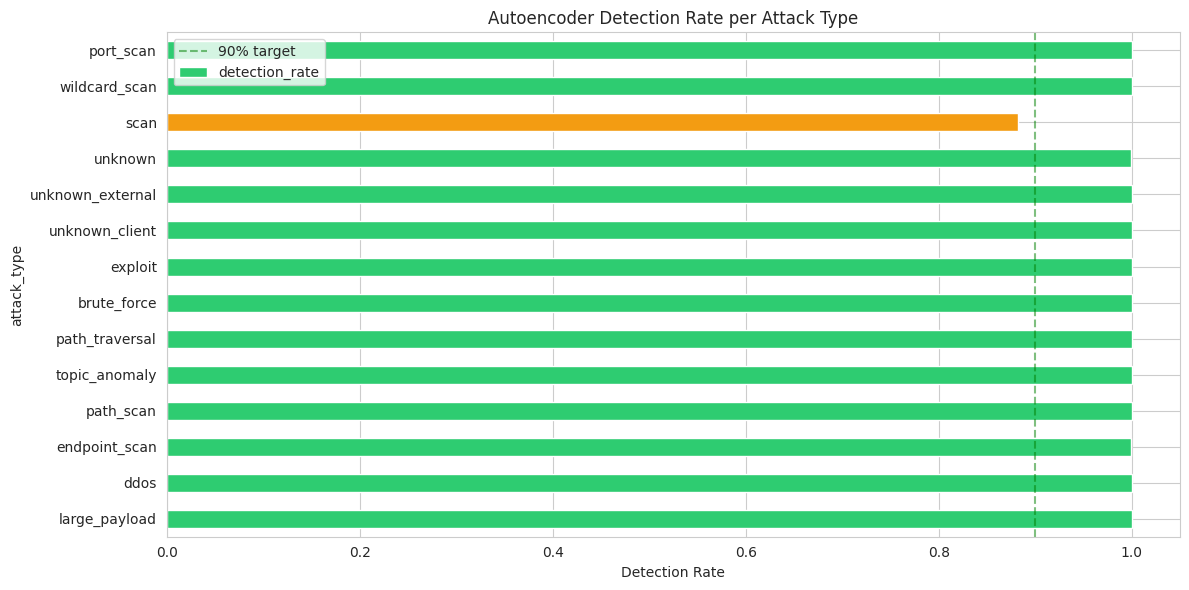

In [13]:
# ================================================================
# Cell 13: Per-Attack-Type Analysis
# ================================================================
# Which attack types are easiest/hardest to detect?
per_type_errors = pd.DataFrame({
    'recon_error': recon_error,
    'attack_type': test_attack_types.values,
    'is_attack': y_test,
})

# Mean reconstruction error per attack type
type_stats = per_type_errors.groupby('attack_type')['recon_error'].agg(['mean', 'std', 'count'])
type_stats['detection_rate'] = per_type_errors.groupby('attack_type').apply(
    lambda g: (g['recon_error'] > threshold).mean()
).values
type_stats = type_stats.sort_values('mean', ascending=False)

print('Per-Attack-Type Detection Analysis:')
print('=' * 70)
print(f"{'Attack Type':<20s} {'Mean Error':>12} {'Std':>10} {'Count':>8} {'Detection %':>12}")
print('-' * 65)
for idx, row in type_stats.iterrows():
    det_str = f"{row['detection_rate']:.1%}"
    print(f"{idx:<20s} {row['mean']:>12.6f} {row['std']:>10.6f} {int(row['count']):>8} {det_str:>12}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
attack_only = type_stats.drop('benign', errors='ignore')
colors = ['#2ecc71' if r >= 0.9 else '#f39c12' if r >= 0.7 else '#e74c3c'
          for r in attack_only['detection_rate']]
attack_only['detection_rate'].plot.barh(ax=ax, color=colors)
ax.axvline(x=0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
ax.set_xlabel('Detection Rate')
ax.set_title('Autoencoder Detection Rate per Attack Type')
ax.legend()
plt.tight_layout()
plt.show()

# Cell 14: Latent Space Visualization (t-SNE)

Embedding shape: (79552, 32)
Running t-SNE (this may take a minute)...


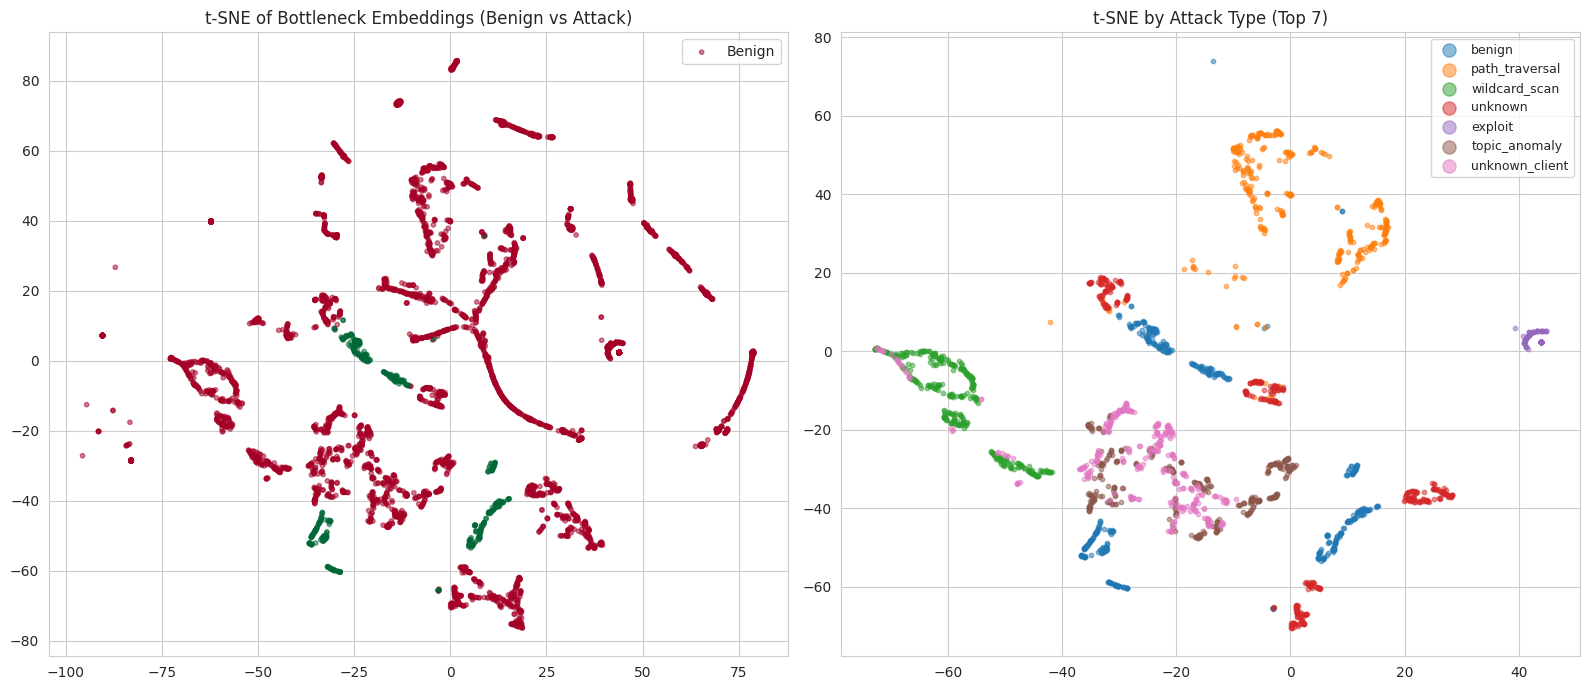

In [14]:
# ================================================================
# Cell 14: Latent Space Visualization (t-SNE)
# ================================================================
from sklearn.manifold import TSNE

# Get bottleneck embeddings for test set
embeddings = encoder.predict(X_test_scaled, verbose=0)
print(f'Embedding shape: {embeddings.shape}')

# Subsample for t-SNE (it's slow on large datasets)
max_samples = 5000
if len(embeddings) > max_samples:
    idx = np.random.RandomState(42).choice(len(embeddings), max_samples, replace=False)
    emb_sub = embeddings[idx]
    y_sub = y_test[idx]
    types_sub = test_attack_types.iloc[idx].values
else:
    emb_sub = embeddings
    y_sub = y_test
    types_sub = test_attack_types.values

# t-SNE
print('Running t-SNE (this may take a minute)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(emb_sub)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Binary coloring
scatter = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1],
                          c=y_sub, cmap='RdYlGn_r', alpha=0.5, s=10)
axes[0].set_title('t-SNE of Bottleneck Embeddings (Benign vs Attack)')
axes[0].legend(*scatter.legend_elements(), labels=['Benign', 'Attack'])

# 2. Per attack type coloring (top 6)
unique_types = pd.Series(types_sub).value_counts().head(7).index
cmap = plt.cm.get_cmap('tab10')
for i, atype in enumerate(unique_types):
    mask = types_sub == atype
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=[cmap(i)], alpha=0.5, s=10, label=atype)
axes[1].set_title('t-SNE by Attack Type (Top 7)')
axes[1].legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.show()

# Cell 15: Save Model

In [15]:
# ================================================================
# Cell 15: Save Model
# ================================================================
import pickle
import json as json_lib

# Save Keras model
autoencoder.save('autoencoder_anomaly.keras')
encoder.save('encoder_anomaly.keras')

# Save scaler
with open('scaler_anomaly.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save metadata
metadata = {
    'model': 'Autoencoder Anomaly Detection',
    'input_dim': input_dim,
    'architecture': '128-BN-64-BN-32(bottleneck)-64-BN-128-BN-output',
    'threshold': float(threshold),
    'threshold_percentile': float(best_row['percentile']),
    'features': feature_names,
    'train_samples_benign': X_train_scaled.shape[0],
    'test_samples': X_test_scaled.shape[0],
    'roc_auc': float(roc_auc),
    'average_precision': float(ap),
    'f1': float(best_row['f1']),
    'precision': float(best_row['precision']),
    'recall': float(best_row['recall']),
}

with open('autoencoder_metadata.json', 'w') as f:
    json_lib.dump(metadata, f, indent=2)

print('Saved: autoencoder_anomaly.keras')
print('Saved: encoder_anomaly.keras')
print('Saved: scaler_anomaly.pkl')
print('Saved: autoencoder_metadata.json')
print(f'\nModel summary:')
for k, v in metadata.items():
    if k != 'features':
        print(f'  {k}: {v}')

Saved: autoencoder_anomaly.keras
Saved: encoder_anomaly.keras
Saved: scaler_anomaly.pkl
Saved: autoencoder_metadata.json

Model summary:
  model: Autoencoder Anomaly Detection
  input_dim: 35
  architecture: 128-BN-64-BN-32(bottleneck)-64-BN-128-BN-output
  threshold: 0.00023172890464720348
  threshold_percentile: 98.0
  train_samples_benign: 26024
  test_samples: 79552
  roc_auc: 0.9974301657982694
  average_precision: 0.9997798189045707
  f1: 0.9947592194465241
  precision: 0.9981941993824438
  recall: 0.9913477993018003
